Week 3 Visualisations – HimShakti Inventory Expiry Analysis

This notebook presents five business-oriented visualizations created using Python for the HimShakti raw material expiry and inventory waste dataset. The purpose of these visualizations is to understand inventory trends, raw material usage, stock composition, relationships between quantity variables, and correlations among numerical features to support better inventory planning and waste reduction decisions.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [ ]:
data = pd.read_csv('/content/HimShakti_Inventory_Expiry_Dataset.csv')
data.head(5)

,Batch_ID,Raw_Material,Entry_Date,Expiry_Date,Quantity_KG,Remaining_Quantity_KG,Production_Date,Finished_Good,Shelf_Life_Days
0,B0001,Onion,2025-10-16,2025-11-28,300,114,2025-10-16,Pickle,170
1,B0002,Tomato,2025-11-23,2026-04-26,482,16,2025-11-25,Pickle,332
2,B0003,Carrot,2024-08-11,2024-10-24,77,71,2024-08-27,Snack Mix,338
3,B0004,Onion,2025-03-05,2025-05-15,334,3,2025-03-19,Dehydrated Mix,331
4,B0005,Potato,2024-12-14,2025-03-10,831,344,2024-12-18,Pickle,140


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Batch_ID               1000 non-null   object
 1   Raw_Material           1000 non-null   object
 2   Entry_Date             1000 non-null   object
 3   Expiry_Date            1000 non-null   object
 4   Quantity_KG            1000 non-null   int64 
 5   Remaining_Quantity_KG  1000 non-null   int64 
 6   Production_Date        1000 non-null   object
 7   Finished_Good          1000 non-null   object
 8   Shelf_Life_Days        1000 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 70.4+ KB


In [ ]:
data['Entry_Date'] = pd.to_datetime(data['Entry_Date'])
data['Expiry_Date'] = pd.to_datetime(data['Expiry_Date'])
data['Production_Date'] = pd.to_datetime(data['Production_Date'])

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Batch_ID               1000 non-null   object        
 1   Raw_Material           1000 non-null   object        
 2   Entry_Date             1000 non-null   datetime64[ns]
 3   Expiry_Date            1000 non-null   datetime64[ns]
 4   Quantity_KG            1000 non-null   int64         
 5   Remaining_Quantity_KG  1000 non-null   int64         
 6   Production_Date        1000 non-null   datetime64[ns]
 7   Finished_Good          1000 non-null   object        
 8   Shelf_Life_Days        1000 non-null   int64         
dtypes: datetime64[ns](3), int64(3), object(3)
memory usage: 70.4+ KB


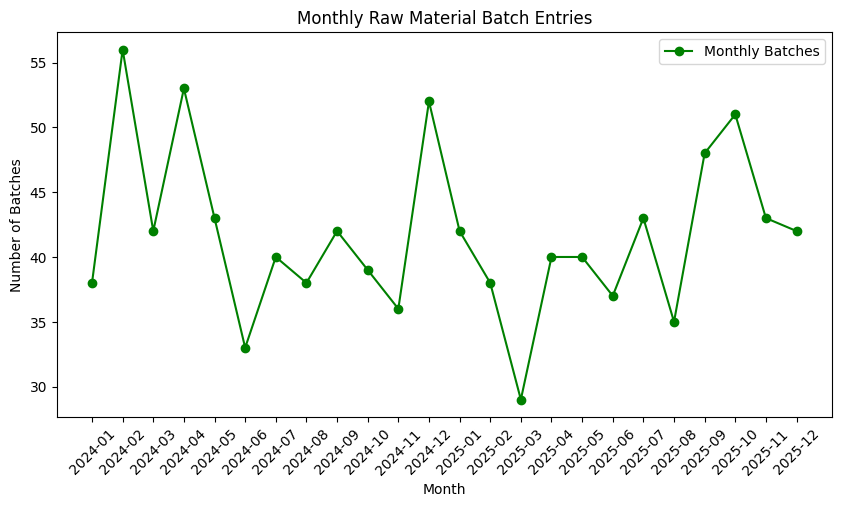

In [ ]:
monthly_batches = data.groupby(
    data['Entry_Date'].dt.to_period('M')
).size()

monthly_batches.index = monthly_batches.index.astype(str)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_batches.index,
    monthly_batches.values,
    marker='o',
    color='green',
    label='Monthly Batches'
)

plt.title("Monthly Raw Material Batch Entries")
plt.xlabel("Month")
plt.ylabel("Number of Batches")
plt.legend()
plt.xticks(rotation=45)

plt.savefig("W3_Chart1_26100250.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files
files.download("W3_Chart1_26100250.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Line Chart – Monthly Raw Material Batch Entries

**Business Question:**  
How do raw material batch entries change over time?

**Why this chart was chosen:**  
A line chart is best suited for showing trends across time periods. In this case, it helps track how the number of raw material batches entered into inventory changes month by month, which is useful for identifying seasonal inventory patterns and planning procurement accordingly.

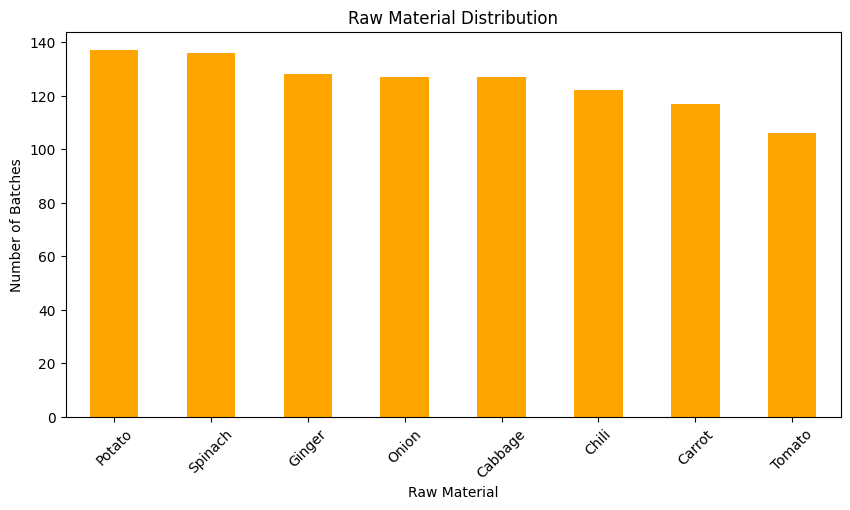

In [ ]:
raw_material_counts = data['Raw_Material'].value_counts()

plt.figure(figsize=(10,5))

raw_material_counts.plot(
    kind='bar',
    color='orange'
)

plt.title("Raw Material Distribution")
plt.xlabel("Raw Material")
plt.ylabel("Number of Batches")
plt.xticks(rotation=45)

plt.savefig("W3_Chart2_26100250.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files
files.download("W3_Chart2_26100250.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Bar Chart – Raw Material Distribution

**Business Question:**  
Which raw materials are used most frequently in the inventory process?

**Why this chart was chosen:**  
A bar chart is ideal for comparing values across multiple categories. Here, it clearly shows which raw materials appear most often in the inventory dataset, helping the business identify high-usage materials that may require tighter stock monitoring and more accurate replenishment planning.

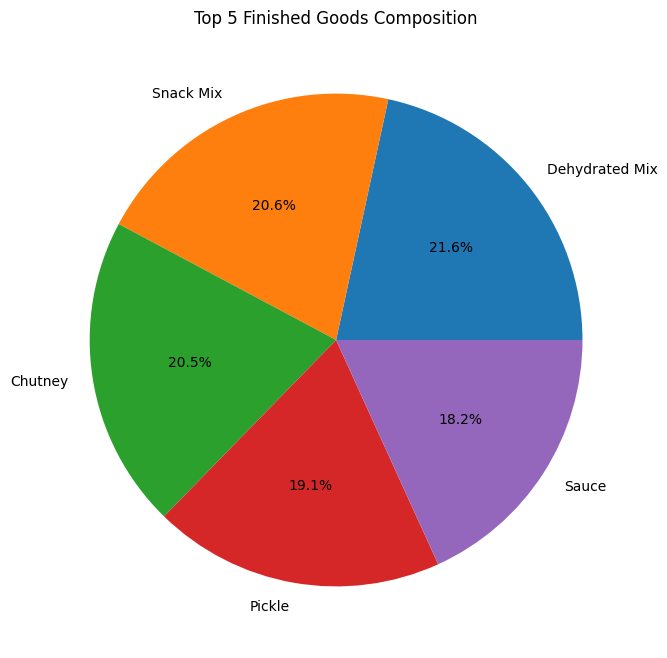

In [ ]:
finished_goods = data['Finished_Good'].value_counts().head(5)

plt.figure(figsize=(8,8))

finished_goods.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Top 5 Finished Goods Composition")
plt.ylabel("")

plt.show()

Pie Chart – Top 5 Finished Goods Composition

**Business Question:**  
What proportion of the inventory is represented by the major finished goods?

**Why this chart was chosen:**  
A pie chart is useful for showing composition or percentage share when the number of categories is limited. By restricting the view to the top five finished goods, the chart highlights how inventory output is distributed across the most important product categories.

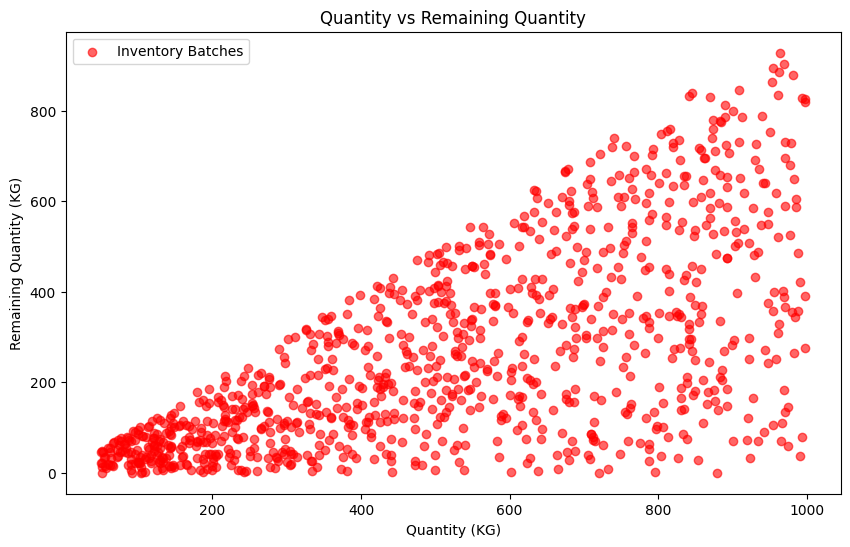

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    data['Quantity_KG'],
    data['Remaining_Quantity_KG'],
    color='red',
    alpha=0.6,
    label='Inventory Batches'
)

plt.title("Quantity vs Remaining Quantity")
plt.xlabel("Quantity (KG)")
plt.ylabel("Remaining Quantity (KG)")
plt.legend()

plt.show()

Scatter Plot – Quantity vs Remaining Quantity

**Business Question:**  
Is there a relationship between the quantity received and the quantity still remaining in inventory?

**Why this chart was chosen:**  
A scatter plot is appropriate for exploring relationships between two numerical variables. This chart helps determine whether larger received quantities tend to result in higher remaining stock, which may indicate slower usage, overstocking, or potential expiry risk.

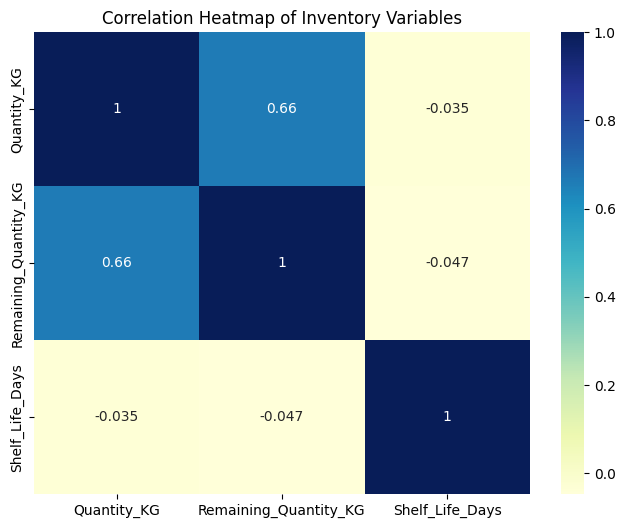

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='YlGnBu'
)

plt.title("Correlation Heatmap of Inventory Variables")

plt.savefig("W3_Chart3_26100250.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files
files.download("W3_Chart3_26100250.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Heatmap – Correlation Heatmap of Inventory Variables

**Business Question:**  
How are the key numerical inventory variables related to each other?

**Why this chart was chosen:**  
A heatmap is effective for visualizing correlations between multiple numerical variables at once. In this dataset, it helps identify whether variables such as quantity, remaining quantity, and shelf life move together, which supports deeper inventory analysis and waste reduction planning.